In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import surfinBH
import lal
import re
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid
import pandas as pd
import gwsurrogate as gws
import warnings
from tqdm.notebook import tqdm
lal.swig_redirect_standard_output_error(True)
warnings.filterwarnings("ignore", category=RuntimeWarning)

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


In [2]:
file_path = '/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q=0.40_chi1=0.20_chi2=0.20_th1=45_th2=45_dphi=90.csv'

In [15]:
fit_1 = surfinBH.LoadFits('NRSur7dq4EmriRemnant')
sur_wave_precessing = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4EmriRemnant fit.
Loaded NRSur7dq4 model


In [16]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)

    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

In [17]:
with open(file_path, 'r') as f:
    f.readline() 
    header_line = f.readline() 

q_prec = float(re.search(r'q=([\d.]+)', header_line).group(1))
chi1 = float(re.search(r'chi1=([\d.]+)', header_line).group(1))
chi2 = float(re.search(r'chi2=([\d.]+)', header_line).group(1))
theta1_0_deg = float(re.search(r'theta1_0_deg=([\d.]+)', header_line).group(1))
theta2_0_deg = float(re.search(r'theta2_0_deg=([\d.]+)', header_line).group(1))
deltaphi_0_deg = float(re.search(r'deltaphi_0_deg=([\d.]+)', header_line).group(1))
theta1_0_rad = np.radians(theta1_0_deg)
theta2_0_rad = np.radians(theta2_0_deg)
phi1_0_rad = 0
phi2_0_rad = np.radians(deltaphi_0_deg)

df = pd.read_csv(file_path, comment='#')
a = df['separation_M']
th1 = df['theta1_rad']
th2 = df['theta2_rad']
dphi = df['deltaphi_rad']

chi1_0_x = chi1 * np.sin(theta1_0_rad) * np.cos(phi1_0_rad)
chi1_0_y = chi1 * np.sin(theta1_0_rad) * np.sin(phi1_0_rad) 
chi1_0_z = chi1 * np.cos(theta1_0_rad)
chi1_0_vec = np.array([chi1_0_x, chi1_0_y, chi1_0_z])

chi2_0_x = chi2 * np.sin(theta2_0_rad) * np.cos(phi2_0_rad)
chi2_0_y = chi2 * np.sin(theta2_0_rad) * np.sin(phi2_0_rad)
chi2_0_z = chi2 * np.cos(theta2_0_rad)
chi2_0_vec = np.array([chi2_0_x, chi2_0_y, chi2_0_z])

chi1_x = chi1 * np.sin(th1)
chi1_y = np.zeros_like(th1)
chi1_z = chi1 * np.cos(th1)
chi1_vec = np.array([chi1_x, chi1_y, chi1_z]) 

chi2_x = chi2 * np.sin(th2) * np.cos(dphi)
chi2_y = chi2 * np.sin(th2) * np.sin(dphi)
chi2_z = chi2 * np.cos(th2)
chi2_vec = np.array([chi2_x, chi2_y, chi2_z])

L_hat = np.array([0.0, 0.0, 1.0])

In [18]:
def get_2PN_precessing(q_precession, chi1_vecs, chi2_vecs, a_arr):

    m1 = q_precession / (1.0 + q_precession)
    m2 = 1.0 / (1.0 + q_precession)
    
    eta = m1 * m2
    delta = m2 - m1  
    
   
    S1_vecs = chi1_vecs * (m1**2)
    S2_vecs = chi2_vecs * (m2**2)
    S_tot_vecs = S1_vecs + S2_vecs

    
    c1_L = chi1_vecs[2, :]
    c2_L = chi2_vecs[2, :]
    S_L = S_tot_vecs[2, :]
    Sigma_L = c2_L * m2 - c1_L * m1
    

    c1_c2 = np.sum(chi1_vecs * chi2_vecs, axis=0)
    c1_sq = np.sum(chi1_vecs**2, axis=0)
    c2_sq = np.sum(chi2_vecs**2, axis=0) 

    e1 = -3.0/4.0 - eta/12.0
    e1_5 = (14.0/3.0) * S_L + 2.0 * delta * Sigma_L
    e2_non_spin = -27.0/8.0 + (19.0/8.0)*eta - (eta**2)/24.0
    e2_SS = 0.5 * eta * (c1_c2 - 3.0 * c1_L * c2_L)
    e2_S1 = 0.25 * (m1**2) * (c1_sq - 3.0 * (c1_L**2))
    e2_S2 = 0.25 * (m2**2) * (c2_sq - 3.0 * (c2_L**2))
    e2_spin = e2_SS + e2_S1 + e2_S2
    e2 = e2_non_spin + e2_spin

    l1 = 3.0/2.0 + eta/6.0
    l1_5 = -(35.0/6.0) * S_L - 2.5 * delta * Sigma_L
    l2_non_spin = 27.0/8.0 - (19.0/8.0)*eta + (eta**2)/24.0
    l2_spin = -e2_spin 
    l2 = l2_non_spin + l2_spin

    with np.errstate(divide='ignore', invalid='ignore'):
        x = 1.0 / a_arr

        E_bind = - (eta * x / 2.0) * (1.0 + e1*x + e1_5*(x**1.5) + e2*(x**2))
        M_tot = 1.0 + E_bind 

        L_orb_mag = (eta / np.sqrt(x)) * (1.0 + l1*x + l1_5*(x**1.5) + l2*(x**2))
        
        L_vecs = np.zeros((3, len(a_arr)))
        L_vecs[2, :] = L_orb_mag
        
        J_vecs = L_vecs + S_tot_vecs
        J_tot_mag = np.linalg.norm(J_vecs, axis=0)
        
    S_inst = entropy(M_tot, J_tot_mag)
    
    return a_arr, M_tot, J_tot_mag, S_inst

In [19]:
a_arr, M_tot, J_tot, S_p = get_2PN_precessing(q_prec, chi1_vec, chi2_vec, a)
a_arr = np.asarray(a_arr)
M_tot = np.asarray(M_tot)
J_tot = np.asarray(J_tot)
S = np.asarray(S_p)

In [20]:
q_surr = 1 / q_prec
mf_surr, chif_vec, *_ = fit_1.all(q_surr, chi1_0_vec, chi2_0_vec)
chif_surr = np.linalg.norm(chif_vec)
Jf_surr = chif_surr * (mf_surr**2)
S_surr_final = entropy(mf_surr, Jf_surr)
print(S_surr_final)

10.296241846150041


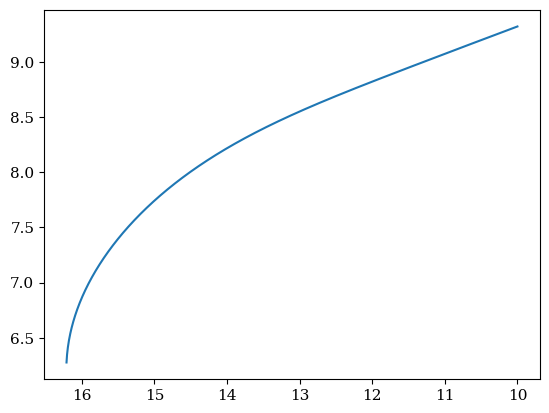

In [21]:
fig,ax = plt.subplots ()
ax.plot(a_arr, S)
ax.invert_xaxis()
plt.show()

PADE'

In [22]:
def pade_2_1(x, a0, a1, a2, b1):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x)

def pade_1_2(x, a0, a1, b1, b2):
    return (a0 + a1*x) / (1 + b1*x + b2*x**2)

def pade_2_2(x, a0, a1, a2, b1, b2):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)

def pade_3_1(x, a0, a1, a2, a3, b1):
    return (a0 + a1*x + a2*x**2 + a3*x**3) / (1 + b1*x)

In [23]:
valid_mask = ~np.isnan(S_p)
a_valid = a_arr[valid_mask]
M_valid = M_tot[valid_mask]
J_valid = J_tot[valid_mask]

sort_idx = np.argsort(a_valid)
a_fit = a_valid[sort_idx]
M_fit = M_valid[sort_idx]
J_fit = J_valid[sort_idx]
S_fit = S[valid_mask][sort_idx]

x_fit = 1.0 / np.sqrt(a_fit)

initial_guess = [1.0, 1.0, 1.0, 1.0]
lower_bounds = [-np.inf, -np.inf, -np.inf, 0.0]
upper_bounds = [np.inf, np.inf, np.inf, np.inf]

popt_M, _ = curve_fit(pade_2_1, x_fit, M_fit, p0=initial_guess, 
                      bounds=(lower_bounds, upper_bounds), maxfev=20000)
popt_J, _ = curve_fit(pade_2_1, x_fit, J_fit, p0=initial_guess, 
                      bounds=(lower_bounds, upper_bounds), maxfev=20000)

a_extrap = np.linspace(np.min(a_fit), 1.0, 1000)
x_extrap = 1.0 / np.sqrt(a_extrap)

M_extrap = pade_2_1(x_extrap, *popt_M)
J_extrap = pade_2_1(x_extrap, *popt_J)
ENT_extrap = entropy(M_extrap, J_extrap)

a_full = np.concatenate([a_fit, a_extrap])
ENT_full = np.concatenate([S_fit, ENT_extrap])

idx_max = np.nanargmax(ENT_full)
a_max_entropy = a_full[idx_max]
S_max_entropy = ENT_full[idx_max]

print(f"Maximum with Padé at a =      {a_max_entropy:.3f}")
print("2PN Padé max entropy =       ", S_max_entropy)
print("Predicted entropy =          ", S_surr_final)
print("Delta S =                    ", np.abs(S_max_entropy - S_surr_final))

Maximum with Padé at a =      6.189
2PN Padé max entropy =        9.694345384965443
Predicted entropy =           10.296241846150041
Delta S =                     0.601896461184598


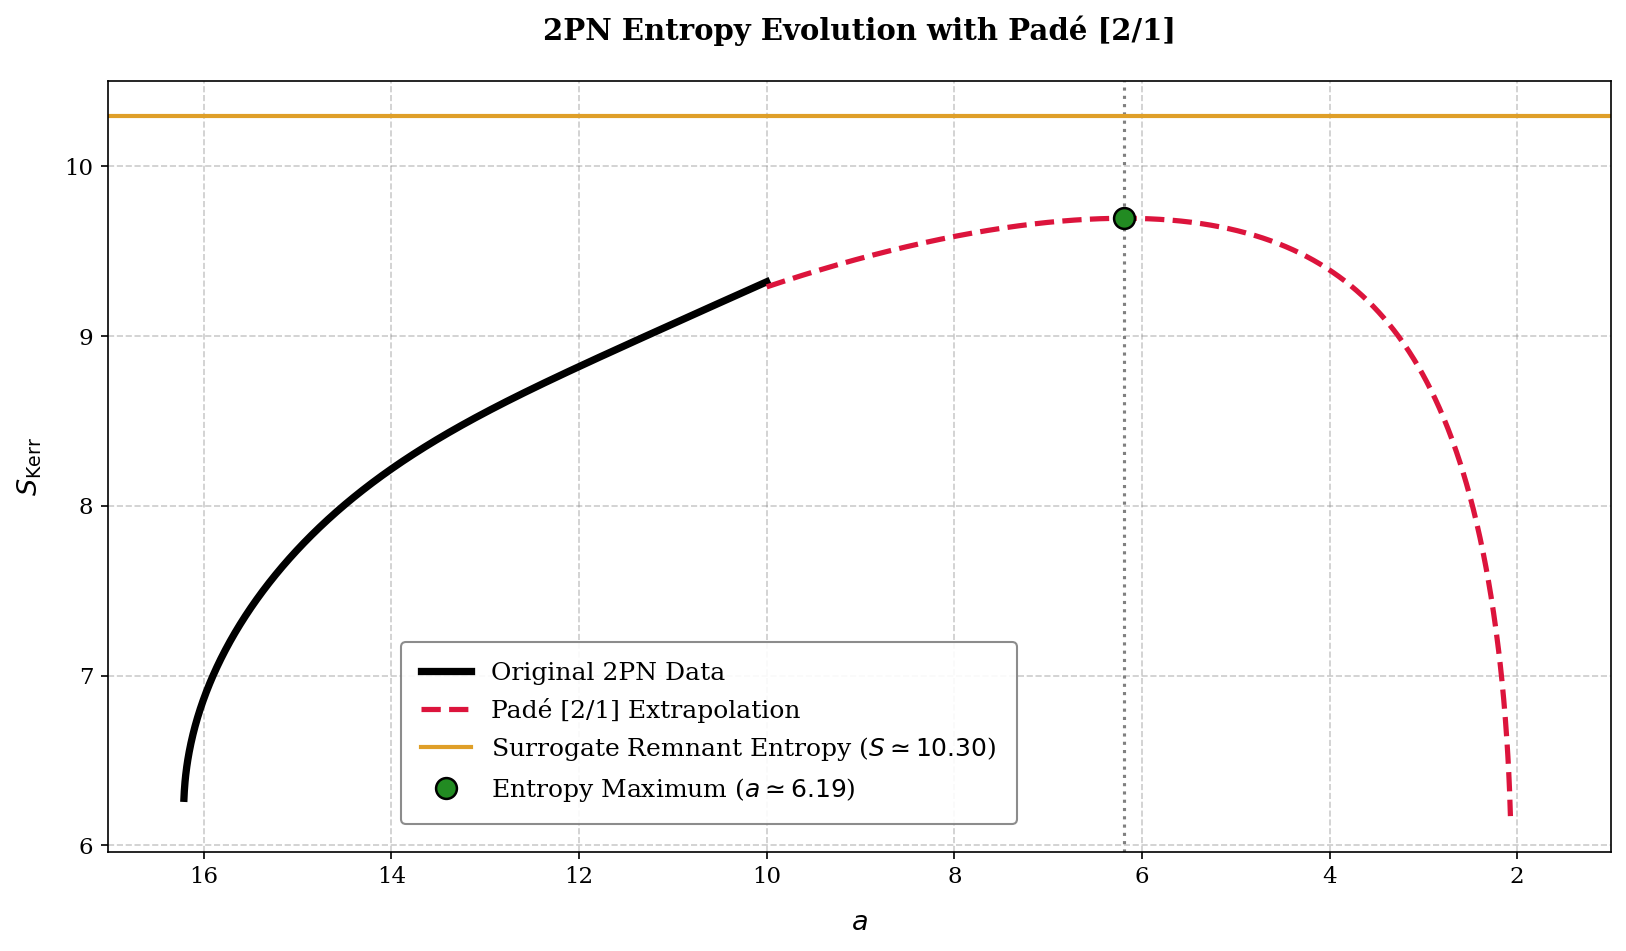

In [24]:
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'font.family': 'serif'
})

fig, ax = plt.subplots(figsize=(11, 6.5), dpi=150)
ax.plot(a_fit, S_fit, color='black', lw=3.5, label='Original 2PN Data')
ax.plot(a_extrap, ENT_extrap, color='#dc143c', linestyle='--', lw=2.5, label='Padé [2/1] Extrapolation')
ax.axhline(y=S_surr_final, color='#df9f28', lw=2.0, linestyle='-', 
           label=rf'Surrogate Remnant Entropy ($S \simeq {S_surr_final:.2f}$)')
ax.axvline(x=a_max_entropy, color='gray', linestyle=':', lw=1.5, zorder=1)
ax.plot(a_max_entropy, S_max_entropy, marker='o', color='#228b22', markersize=10, 
        markeredgecolor='black', markeredgewidth=1.2, linestyle='none', zorder=5,
        label=rf'Entropy Maximum ($a \simeq {a_max_entropy:.2f}$)')
ax.invert_xaxis()
x_max_plot = np.max(a_fit) * 1.05
ax.set_xlim(x_max_plot, 1.0)
y_min_plot = np.nanmin(S_fit) * 0.95
y_max_plot = max(S_max_entropy, S_surr_final) * 1.02
ax.set_ylim(y_min_plot, y_max_plot)
ax.set_xlabel(r'$a$', fontweight='bold', labelpad=10)
ax.set_ylabel(r'$S_{\mathrm{Kerr}}$', fontweight='bold', labelpad=10)
ax.set_title('2PN Entropy Evolution with Padé [2/1]', fontweight='bold', pad=20)
ax.grid(True, which='both', linestyle='--', alpha=0.4, color='gray')
ax.legend(loc='lower center', bbox_to_anchor=(0.4, 0.02), frameon=True, 
          facecolor='white', edgecolor='gray', framealpha=0.9, shadow=False, borderpad=0.8)

plt.tight_layout()
plt.show()

In [29]:
def simulate_conjecture_2PN_precessing(q_prec, chi1_vec, chi2_vec, f_low=0.01):
   
    if q_prec < 1.0:
        q_surr = 1.0 / q_prec
        chi_surr_1 = np.asarray(chi2_vec, dtype=float) 
        chi_surr_2 = np.asarray(chi1_vec, dtype=float) 
    else:
        q_surr = q_prec
        chi_surr_1 = np.asarray(chi1_vec, dtype=float)
        chi_surr_2 = np.asarray(chi2_vec, dtype=float)

    t, h, _ = sur_wave_precessing(q_surr, chi_surr_1, chi_surr_2, dt=0.1, f_low=f_low)
    
    h22 = h[(2, 2)]
    phase_22 = np.unwrap(np.angle(h22))
    omega_22 = np.abs(np.gradient(phase_22, t))
    omega_orb = omega_22 / 2.0
    r_inst = (np.maximum(omega_orb, 1e-8))**(-2.0 / 3.0)
    
    E_dot = np.zeros_like(t)
    J_dot = np.zeros((3, len(t))) 
    
    for (l, m), h_lm in h.items():
        h_dot = np.gradient(h_lm, t)
        E_dot += np.abs(h_dot)**2
        J_dot[2, :] += m * np.imag(h_lm * np.conj(h_dot))
        

        if (l, m + 1) in h:
            h_lmp1 = h[(l, m + 1)]
            h_lmp1_dot = np.gradient(h_lmp1, t)
            
            c_lm = np.sqrt(l * (l + 1) - m * (m + 1))
            term1 = h_lm * np.conj(h_lmp1_dot)
            term2 = h_lmp1 * np.conj(h_dot)
            
            J_dot[0, :] += 0.5 * c_lm * np.imag(term1 + term2)
            J_dot[1, :] -= 0.5 * c_lm * np.real(term1 - term2)
            
    E_dot /= (16.0 * np.pi)
    J_dot /= (16.0 * np.pi)
    
    E_rad = cumulative_trapezoid(E_dot, t, initial=0)
    J_rad_x = cumulative_trapezoid(J_dot[0, :], t, initial=0)
    J_rad_y = cumulative_trapezoid(J_dot[1, :], t, initial=0)
    J_rad_z = cumulative_trapezoid(J_dot[2, :], t, initial=0)
    J_rad = np.array([J_rad_x, J_rad_y, J_rad_z])
    
    idx_relax = min(50, len(t) - 1)
    r_0 = r_inst[idx_relax]
    
    chi1_in = np.asarray(chi1_vec).reshape(3, 1)
    chi2_in = np.asarray(chi2_vec).reshape(3, 1)
    
    _, M_init_arr, J_init_mag_arr, _ = get_2PN_precessing(q_prec, chi1_in, chi2_in, np.array([r_0]))
    M_init = M_init_arr[0]
    J_init_mag = J_init_mag_arr[0]
    
    m1_prec = q_prec / (1.0 + q_prec)
    m2_prec = 1.0 / (1.0 + q_prec)
    S_tot_init = np.asarray(chi1_vec) * (m1_prec**2) + np.asarray(chi2_vec) * (m2_prec**2)
    
    J_init_z = np.sqrt(np.maximum(J_init_mag**2 - S_tot_init[0]**2 - S_tot_init[1]**2, 0.0))
    J_init_vec = np.array([S_tot_init[0], S_tot_init[1], J_init_z])
    
    E_rad -= E_rad[idx_relax]
    J_rad[0, :] -= J_rad[0, idx_relax]
    J_rad[1, :] -= J_rad[1, idx_relax]
    J_rad[2, :] -= J_rad[2, idx_relax]
    
    M_inst = M_init - E_rad
    J_inst_vec = J_init_vec[:, np.newaxis] - J_rad
    J_inst_mag = np.linalg.norm(J_inst_vec, axis=0)
    
    a_inst = J_inst_mag / (M_inst**2)
    
    valid = a_inst <= 1.0
    if not np.any(valid):
        return None
    
    t_valid = t[valid]
    a_valid = a_inst[valid]
    M_valid = M_inst[valid]
    J_valid = J_inst_mag[valid]  
    r_valid = r_inst[valid]
    
    S_Kerr = entropy(M_valid, J_valid)
    
    return {
        't': t_valid, 
        'a_inst': a_valid, 
        'S_Kerr': S_Kerr,   
        'r': r_valid,
        'M': M_valid,
        'J': J_valid,
        'J_vec': J_inst_vec[:, valid]
    }

In [30]:
risultato = simulate_conjecture_2PN_precessing(q_prec, chi1_0_vec, chi2_0_vec, f_low=0.01)